# Exploratory Data Analysis - WFP Nigeria Food Prices

This notebook performs exploratory data analysis (EDA) on the WFP Nigeria food prices dataset to support the crop price prediction model for smallholder farmers.

## Notebook Outline
- 1. Load Data
- 2. Data Cleaning
- 3. Feature Extraction
- 4. Exploratory Analysis
- 5. Visualizations
- 6. Save Cleaned Data

## 1. Load Data

Load the WFP Nigeria food prices CSV, skipping the second header row that contains metadata tags.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plots
sns.set(style="whitegrid")

# Paths (notebook lives in notebooks/, data lives one level up)
DATA_RAW_PATH = Path("../data/raw/wfp_food_prices_nga.csv")

# Load CSV, skipping the second row (index 1) that contains metadata tags
# Row 0 is the true header row with column names
_df = pd.read_csv(DATA_RAW_PATH, skiprows=[1])

print("Original shape:", _df.shape)
print("\nFirst 5 rows:")
display(_df.head())

print("\nColumns and dtypes:")
print(_df.dtypes)

Original shape: (60565, 16)

First 5 rows:


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,175.92,1.54
1,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Millet,73,KG,actual,Wholesale,NGN,150.18,1.31
2,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Rice (imported),64,KG,actual,Wholesale,NGN,358.70,3.14
3,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Sorghum,65,KG,actual,Wholesale,NGN,155.61,1.36
4,2002-01-15,Sokoto,Gada,Illela (CBM),1037,13.64,5.28,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,153.35,1.34



Columns and dtypes:
date             object
admin1           object
admin2           object
market           object
market_id         int64
latitude        float64
longitude       float64
category         object
commodity        object
commodity_id      int64
unit             object
priceflag        object
pricetype        object
currency         object
price           float64
usdprice        float64
dtype: object


## 2. Data Cleaning

- Parse `date` as datetime
- Keep both `Wholesale` and `Retail` in `pricetype`
- Keep `KG`, `G`, and `100 g` units and convert all prices to per-KG values
- Set `unit = 'KG'` after conversion
- Drop columns not needed for ML
- Remove rows where `price` is 0 or null
- Remove duplicates
- Show shapes before and after cleaning, `pricetype` breakdown, and missing value counts.

In [39]:
df = _df.copy()

print("Shape before cleaning:", df.shape)

# Parse date column as datetime
if not pd.api.types.is_datetime64_any_dtype(df["date"]):
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Keep both Wholesale and Retail price types
# (pricetype column is retained for use as a future feature)
df = df[df["pricetype"].isin(["Wholesale", "Retail"])]

# Keep KG, G, and 100 g units, then convert all prices to per-KG basis
df = df[df["unit"].isin(["KG", "G", "100 g"])]

# Convert price to numeric before unit-based transformation
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Unit normalization to KG-equivalent prices
# G -> multiply by 1000, 100 g -> multiply by 10, KG -> unchanged
df.loc[df["unit"] == "G", "price"] = df.loc[df["unit"] == "G", "price"] * 1000
df.loc[df["unit"] == "100 g", "price"] = df.loc[df["unit"] == "100 g", "price"] * 10
df.loc[df["unit"] == "KG", "price"] = df.loc[df["unit"] == "KG", "price"]

# Set unit to KG for all retained rows after conversion
df["unit"] = "KG"

# Drop columns not needed for ML
cols_to_drop = [
    "market_id",
    "commodity_id",
    "latitude",
    "longitude",
    "currency",
    "usdprice",
    "priceflag",
]
df = df.drop(columns=cols_to_drop, errors="ignore")

# Remove rows with price null or 0
df = df.copy()
df = df[df["price"].notna()]
df = df[df["price"] != 0]

# Remove rows with invalid dates
df = df[df["date"].notna()]

# Remove duplicate rows
before_dedup = df.shape[0]
df = df.drop_duplicates()
after_dedup = df.shape[0]

# Show available commodities before final category filter
print("Unique commodities before category filter:")
print(sorted(df["commodity"].dropna().unique()))

# Keep only agricultural crop categories (exact case-sensitive values)
EXCLUDED_CATEGORIES = ["meat", "fish", "oil"]
KEEP_CATEGORIES = ["cereals and tubers", "pulses and nuts", "vegetables and fruits"]
df = df[df["category"].isin(KEEP_CATEGORIES)]

print("Shape after category filter:", df.shape)
print("\nTop 10 commodities after category filter:")
print(df["commodity"].value_counts().head(10))
print("\nPricetype breakdown after category filter:")
print(df["pricetype"].value_counts())

print("\nShape after cleaning:", df.shape)
print("Rows removed as duplicates:", before_dedup - after_dedup)

print("\nPricetype breakdown after cleaning:")
print(df["pricetype"].value_counts())

print("\nMissing values per column (after cleaning):")
print(df.isna().sum())

Shape before cleaning: (60565, 16)
Unique commodities before category filter:
['Beans (niebe)', 'Cassava meal (gari, yellow)', 'Cowpeas (brown)', 'Cowpeas (white)', 'Fish', 'Gari (white)', 'Groundnuts (shelled)', 'Maize', 'Maize (white)', 'Maize (yellow)', 'Meat (beef)', 'Meat (goat)', 'Millet', 'Rice (imported)', 'Rice (local)', 'Sorghum', 'Sorghum (brown)', 'Sorghum (white)', 'Wheat', 'Yam', 'Yam (Abuja)']
Shape after category filter: (9107, 9)

Top 10 commodities after category filter:
commodity
Millet                  1050
Yam                      852
Rice (imported)          804
Cowpeas (white)          607
Sorghum (brown)          571
Sorghum (white)          566
Gari (white)             552
Maize (white)            543
Rice (local)             536
Groundnuts (shelled)     536
Name: count, dtype: int64

Pricetype breakdown after category filter:
pricetype
Retail       7336
Wholesale    1771
Name: count, dtype: int64

Shape after cleaning: (9107, 9)
Rows removed as duplicates: 0



## 3. Feature Extraction

Extract `year` and `month` from the `date` column as new features.

In [40]:
# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Extract year and month
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

print("Sample of dataframe with new features:")
display(df.head())

Sample of dataframe with new features:


,date,admin1,admin2,market,category,commodity,unit,pricetype,price,year,month
0,2002-01-15,Katsina,Jibia,Jibia (CBM),cereals and tubers,Maize,KG,Wholesale,175.92,2002,1
1,2002-01-15,Katsina,Jibia,Jibia (CBM),cereals and tubers,Millet,KG,Wholesale,150.18,2002,1
2,2002-01-15,Katsina,Jibia,Jibia (CBM),cereals and tubers,Rice (imported),KG,Wholesale,358.70,2002,1
3,2002-01-15,Katsina,Jibia,Jibia (CBM),cereals and tubers,Sorghum,KG,Wholesale,155.61,2002,1
4,2002-01-15,Sokoto,Gada,Illela (CBM),cereals and tubers,Maize,KG,Wholesale,153.35,2002,1


## 4. Exploratory Analysis

- Value counts for `commodity`
- Value counts for `admin1`
- Basic statistics of `price` grouped by `commodity`.

In [41]:
print("Value counts for commodity (top 20):")
print(df["commodity"].value_counts().head(20))

print("\nValue counts for admin1 (top 20):")
print(df["admin1"].value_counts().head(20))

print("\nPrice statistics by commodity:")
price_stats = df.groupby("commodity")["price"].agg(["count", "mean", "min", "max", "std"]).sort_values("count", ascending=False)
display(price_stats.head(20))

Value counts for commodity (top 20):
commodity
Millet                         1050
Yam                             852
Rice (imported)                 804
Cowpeas (white)                 607
Sorghum (brown)                 571
Sorghum (white)                 566
Gari (white)                    552
Maize (white)                   543
Rice (local)                    536
Groundnuts (shelled)            536
Maize (yellow)                  532
Maize                           529
Cassava meal (gari, yellow)     508
Cowpeas (brown)                 487
Sorghum                         342
Wheat                            47
Yam (Abuja)                      27
Beans (niebe)                    18
Name: count, dtype: int64

Value counts for admin1 (top 20):
admin1
Katsina    1140
Borno      1134
Yobe        916
Kaduna      833
Jigawa      688
Oyo         563
Abia        529
Kebbi       514
Zamfara     485
Kano        485
Sokoto      481
Lagos       461
Adamawa     451
Gombe       427
Name: count, 

,count,mean,min,max,std
commodity,,,,,
Millet,1050,180.837419,50.92,411.22,60.021199
Yam,852,288.364120,22.00,1645.58,229.313537
Rice (imported),804,455.609378,94.34,1076.49,150.689573
Cowpeas (white),607,343.461944,76.47,846.20,163.895080
Sorghum (brown),571,182.013135,40.00,469.88,80.840743
Sorghum (white),566,181.507314,50.00,471.31,80.364284
Gari (white),552,271.882754,39.03,1836.89,127.975328
Maize (white),543,170.472394,57.41,345.27,65.830564
Rice (local),536,366.257127,100.66,781.42,114.835231


## 5. Visualizations

Create and save the following plots to `data/processed/`:

1. Price distribution by commodity (boxplot, top 10 commodities).
2. Monthly average price trend for top 5 commodities.
3. Market coverage by state (unique markets per `admin1`).
4. Yearly average price trend by commodity (top 5 commodities).

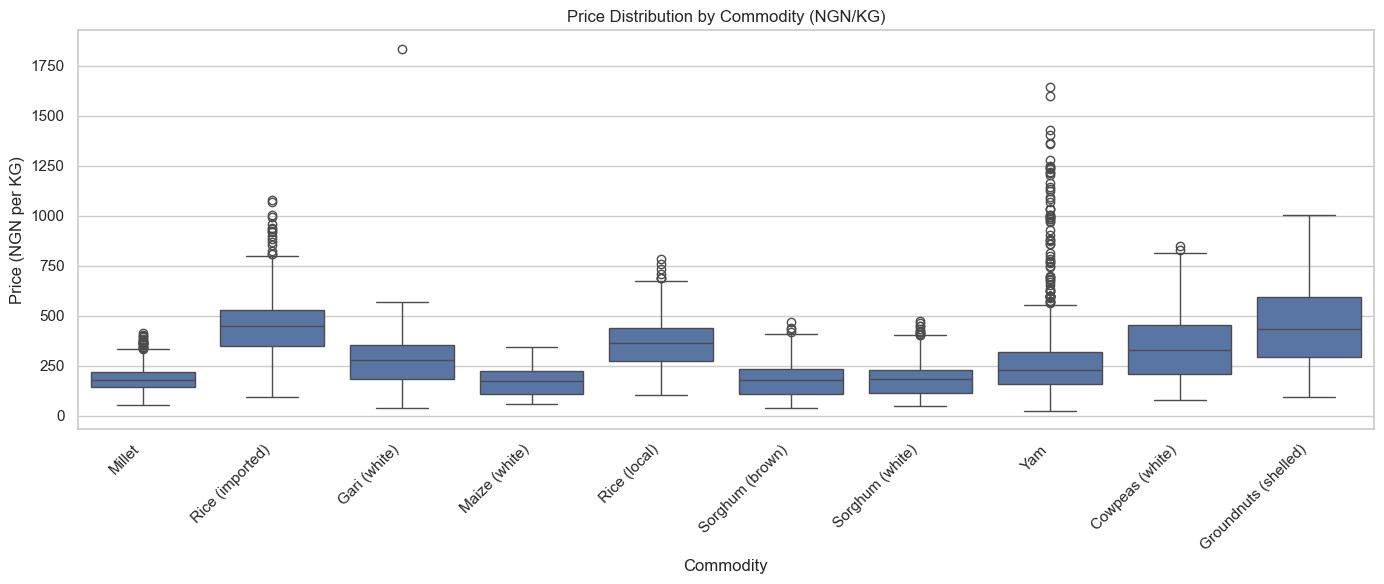

Plot 1 saved to: ..\data\processed\plot1_price_distribution_by_commodity.png


In [42]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Determine top commodities by record count
top_commodities = df["commodity"].value_counts().head(10).index

df_top_commodities = df[df["commodity"].isin(top_commodities)].copy()

# Plot 1 — Price distribution by commodity (boxplot)
plt.figure(figsize=(14, 6))
ax = sns.boxplot(data=df_top_commodities, x="commodity", y="price")
plt.xticks(rotation=45, ha="right")
plt.title("Price Distribution by Commodity (NGN/KG)")
plt.xlabel("Commodity")
plt.ylabel("Price (NGN per KG)")
plt.tight_layout()

plot1_path = processed_dir / "plot1_price_distribution_by_commodity.png"
plt.savefig(plot1_path, bbox_inches="tight")
plt.show()

print(f"Plot 1 saved to: {plot1_path}")

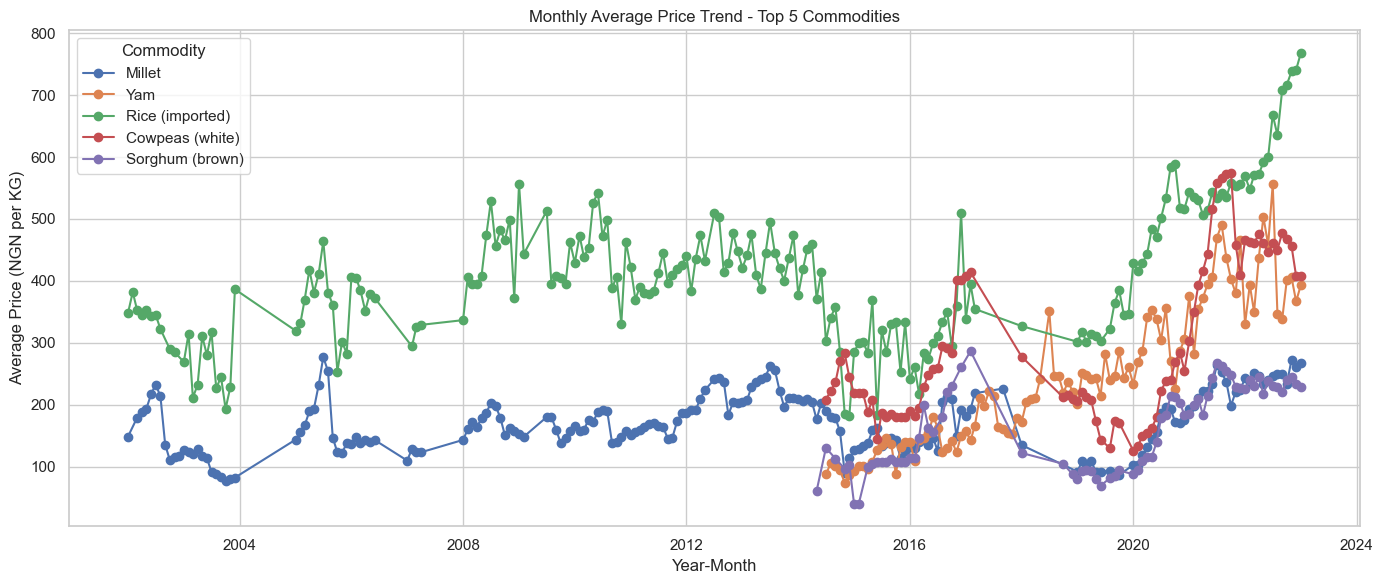

Plot 2 saved to: ..\data\processed\plot2_monthly_avg_price_trend_top5.png


In [43]:
# Prepare data for monthly price trend (top 5 commodities)
top5_commodities = df["commodity"].value_counts().head(5).index

df_top5 = df[df["commodity"].isin(top5_commodities)].copy()

# Create a year-month column
df_top5["year_month"] = df_top5["date"].dt.to_period("M").dt.to_timestamp()

monthly_trend = (
    df_top5
    .groupby(["year_month", "commodity"])["price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))
for commodity in top5_commodities:
    subset = monthly_trend[monthly_trend["commodity"] == commodity]
    plt.plot(subset["year_month"], subset["price"], marker="o", label=commodity)

plt.title("Monthly Average Price Trend - Top 5 Commodities")
plt.xlabel("Year-Month")
plt.ylabel("Average Price (NGN per KG)")
plt.legend(title="Commodity")
plt.tight_layout()

plot2_path = processed_dir / "plot2_monthly_avg_price_trend_top5.png"
plt.savefig(plot2_path, bbox_inches="tight")
plt.show()

print(f"Plot 2 saved to: {plot2_path}")

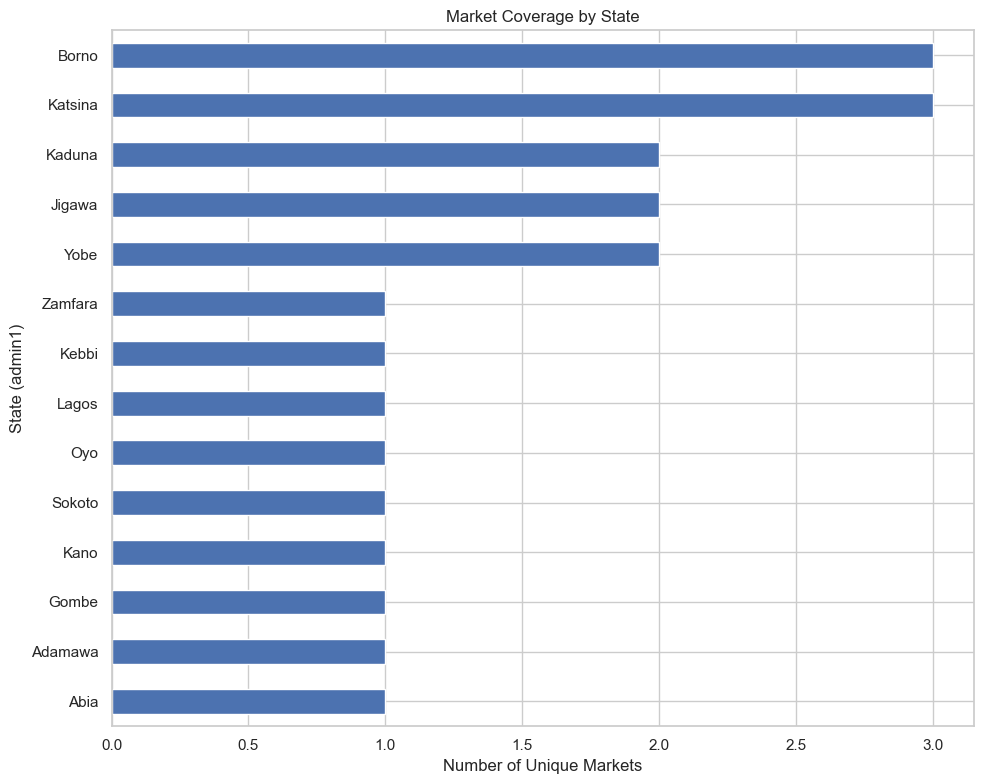

Plot 3 saved to: ..\data\processed\plot3_market_coverage_by_state.png


In [44]:
# Plot 3 — State coverage: number of unique markets per state (admin1)
state_market_counts = (
    df.groupby("admin1")["market"]
    .nunique()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 8))
state_market_counts.plot(kind="barh")
plt.title("Market Coverage by State")
plt.xlabel("Number of Unique Markets")
plt.ylabel("State (admin1)")
plt.tight_layout()

plot3_path = processed_dir / "plot3_market_coverage_by_state.png"
plt.savefig(plot3_path, bbox_inches="tight")
plt.show()

print(f"Plot 3 saved to: {plot3_path}")

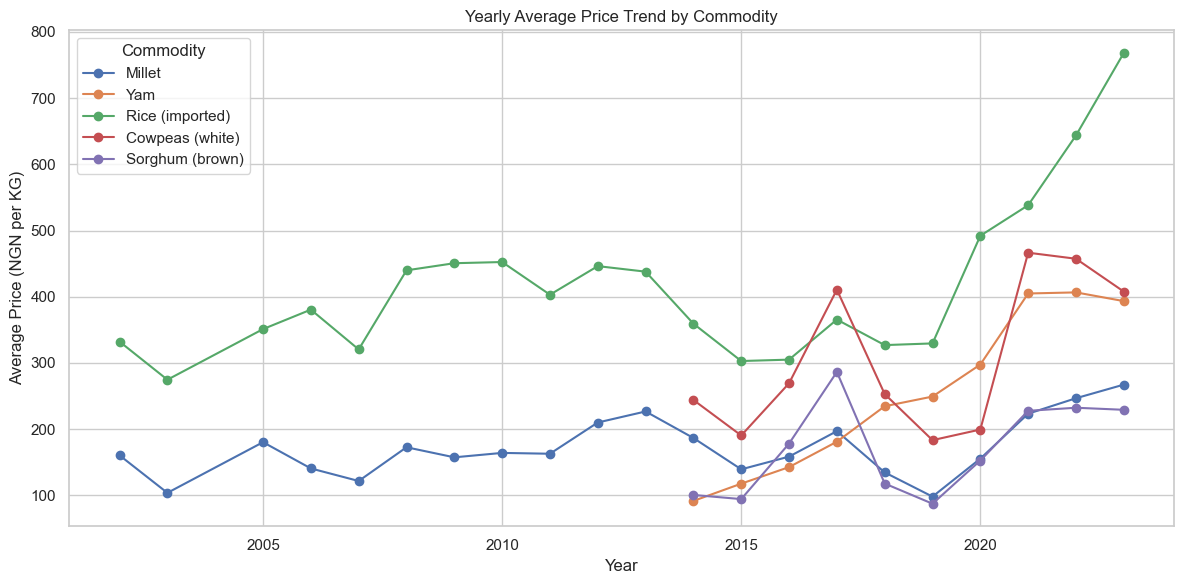

Plot 4 saved to: ..\data\processed\plot4_yearly_avg_price_trend_top5.png


In [45]:
# Plot 4 — Yearly average price trend by commodity (top 5 commodities)

yearly_trend = (
    df[df["commodity"].isin(top5_commodities)]
    .groupby(["year", "commodity"])["price"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
for commodity in top5_commodities:
    subset = yearly_trend[yearly_trend["commodity"] == commodity]
    plt.plot(subset["year"], subset["price"], marker="o", label=commodity)

plt.title("Yearly Average Price Trend by Commodity")
plt.xlabel("Year")
plt.ylabel("Average Price (NGN per KG)")
plt.legend(title="Commodity")
plt.tight_layout()

plot4_path = processed_dir / "plot4_yearly_avg_price_trend_top5.png"
plt.savefig(plot4_path, bbox_inches="tight")
plt.show()

print(f"Plot 4 saved to: {plot4_path}")

## 6. Save Cleaned Data

Save the cleaned dataframe to `data/processed/cleaned_prices.csv` for downstream modelling.

In [46]:
cleaned_path = processed_dir / "cleaned_prices.csv"

df.to_csv(cleaned_path, index=False)

print(f"Cleaned data saved to: {cleaned_path}")
print("Final cleaned shape:", df.shape)

Cleaned data saved to: ..\data\processed\cleaned_prices.csv
Final cleaned shape: (9107, 11)
